In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
face_cascade = cv2.CascadeClassifier('../Data/haarcascade_frontalface_default.xml')

In [3]:
def detect_face(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    if len(faces) == 0:
        return None

    # Assuming the first detected face is the main one
    x, y, w, h = faces[0]
    face = image[y:y+h, x:x+w]
    face = cv2.resize(face, (224, 224)) # Resize face to the size expected by VGG16
    return face

In [9]:
# Define dataset paths
train_dir = '../Data/CK+_Updated/train'
test_dir = '../Data/CK+_Updated/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load the data with ImageDataGenerator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224), #VGG16 input size
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 228 images belonging to 6 classes.
Found 97 images belonging to 6 classes.


In [10]:
# Load the data with ImageDataGenerator (but modify images to detect faces first)
def preprocess_data_generator(directory, batch_size=32, is_test=False):

    image_files = [f for f in os.listdir(directory) if f.endswith('.jpg') or f.endswith('.png')]
    images = []
    labels = []

    for file in image_files:
        image_path = os.path.join(directory, file)
        print(image_path)
        img = cv2.imread(image_path)

        # Detect face from the image
        face = detect_face(img)

        if face is not None:
            # Resize the face image and normalize it (VGG16 input size is 224*244)
            face = np.expand_dims(face, axis=0) # Add batch dimension
            face = np.array(face) # Convert to numpy array

            # Get corresponding label (assuming label is part of filename, modify as needed)
            label = int(file.split('_')[0])

            images.append(face)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    # Convert to categorical labels
    labels = keras.utils.to_categorical(labels, num_classes=6)

    return images, labels

In [16]:
def get_path(directory):
    print(directory)
    image_files = [f for f in os.listdir(directory) if f.endswith('.jpg') or f.endswith('.png')]
    print(image_files.__len__())
    counter = 0
    for file in image_files:
        image_path = os.path.join(directory, file)
        print(image_path)

        if counter > 10:
            break

        counter += 1


In [17]:
get_path(train_dir)
get_path(test_dir)

../Data/CK+_Updated/train
0
../Data/CK+_Updated/test
0


In [11]:
# Use the custom data generator for training and testing
train_images, train_labels = preprocess_data_generator(train_dir)
test_images, test_labels = preprocess_data_generator(test_dir)

In [7]:
# Load pre-trained VGG16 model (excluding the top layer)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base (don´t train these layers)
for layer in base_model.layers:
    layer.trainable = False

#base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
# Correctly connect new classification layers
x = Flatten()(base_model.output) # Flatten the output of convolutional base
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(6, activation='softmax')(x) # Final output layer

# Create the model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

#model.summary()

In [19]:
# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=test_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator)
)

# Evaluate on the test dataset
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test loss: {test_loss * 100:.2f}; Test accuracy: {test_acc * 100:.2f}')

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6535 - loss: 0.9275 - val_accuracy: 0.6289 - val_loss: 0.8951
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6447 - loss: 0.9565 - val_accuracy: 0.6186 - val_loss: 0.9367
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6447 - loss: 0.9136 - val_accuracy: 0.7320 - val_loss: 0.8948
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6754 - loss: 0.9095 - val_accuracy: 0.6392 - val_loss: 0.9388
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.6754 - loss: 0.9347 - val_accuracy: 0.6804 - val_loss: 0.8999
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6974 - loss: 0.8453 - val_accuracy: 0.6701 - val_loss: 0.9340
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6491 - loss: 0.8835 - val_accuracy: 0.6598 - val_loss: 0.8785
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.7105 - loss: 0.8396 - val_accuracy: 0.5979 - val_loss: 0.9665
Epoch 9/

In [20]:
model.save('./face_expression_model_tf.h5')

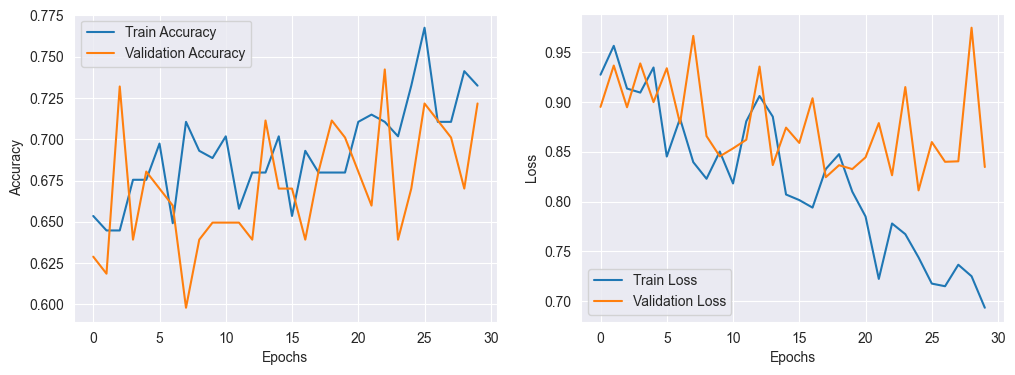

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

Found 97 images belonging to 6 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 971ms/step


<Figure size 800x600 with 0 Axes>

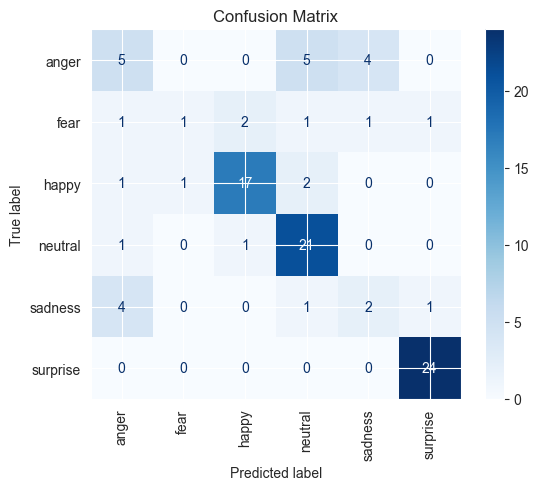

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

eval_test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

predictions = model.predict(eval_test_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = eval_test_generator.classes

class_labels = list(eval_test_generator.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


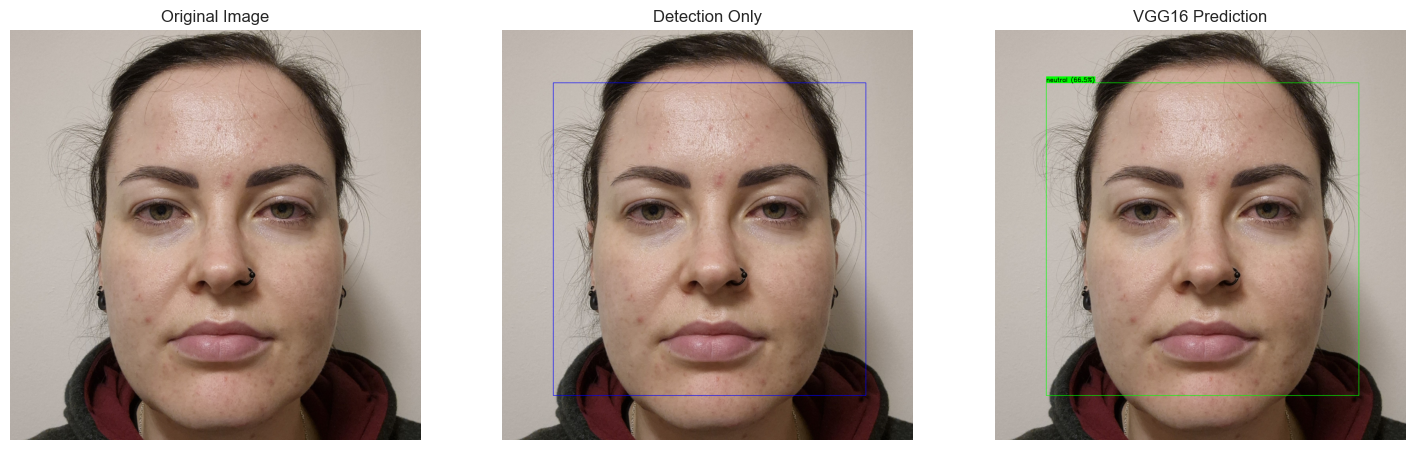

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Update dimensions to match VGG16 requirements
img_height, img_width = 224, 224

# 2. Update labels to match your directory structure/labels
# Ensure these match the alphabetical order of your subfolders or eval_test_generator.class_indices
expressions = ['anger', 'fear', 'happy', 'neutral', 'sadness', 'surprise']

# Load the face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 3. Updated Preprocessing for VGG16
def preprocess_face(face_bgr):
    # VGG16 expects 3 channels (RGB). OpenCV reads in BGR, so we convert.
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    face_resized = cv2.resize(face_rgb, (img_height, img_width))

    # Normalize pixel values (to 0-1) to match your ImageDataGenerator(rescale=1./255)
    face_normalized = face_resized.astype("float32") / 255.0

    # Add batch dimension: (1, 224, 224, 3)
    face_batch = np.expand_dims(face_normalized, axis=0)
    return face_batch

# Path to the test image
#img_path = '../Data/assignment/CK_dataset/happy/20251201_195833.jpg'
img_path = '../Data/assignment/CK_dataset/neutral/20251201_200909.jpg'

# Read the original image
original_img = cv2.imread(img_path)
if original_img is None:
    print(f"Error: Could not load image at {img_path}")
else:
    # Face detection works best on grayscale, but prediction needs color
    gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, scaleFactor=1.3, minNeighbors=5)

    face_detected_img = original_img.copy()
    final_img = original_img.copy()

    for (x, y, w, h) in faces:
        # Extract face ROI in color (BGR)
        face_roi = original_img[y:y+h, x:x+w]

        # Preprocess for VGG16 (resizes to 224, converts to RGB, normalizes)
        processed_face = preprocess_face(face_roi)

        # Get prediction
        prediction = model.predict(processed_face)
        predicted_class = np.argmax(prediction, axis=1)
        predicted_emotion = expressions[predicted_class[0]]
        confidence = np.max(prediction) * 100

        # Draw bounding boxes
        cv2.rectangle(face_detected_img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.rectangle(final_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # UI Styling
        label = f"{predicted_emotion} ({confidence:.1f}%)"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.0 # Adjusted scale for 224x224 context
        font_thickness = 2

        (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, font_thickness)
        cv2.rectangle(final_img, (x, y - text_height - 10), (x + text_width, y), (0, 255, 0), -1)
        cv2.putText(final_img, label, (x, y - 5), font, font_scale, (0, 0, 0), font_thickness)

    # Convert for display
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    face_detected_img_rgb = cv2.cvtColor(face_detected_img, cv2.COLOR_BGR2RGB)
    final_img_rgb = cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(original_img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(face_detected_img_rgb)
    axes[1].set_title("Detection Only")
    axes[1].axis("off")

    axes[2].imshow(final_img_rgb)
    axes[2].set_title("VGG16 Prediction")
    axes[2].axis("off")

    plt.show()